In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv("data/final_df.csv")

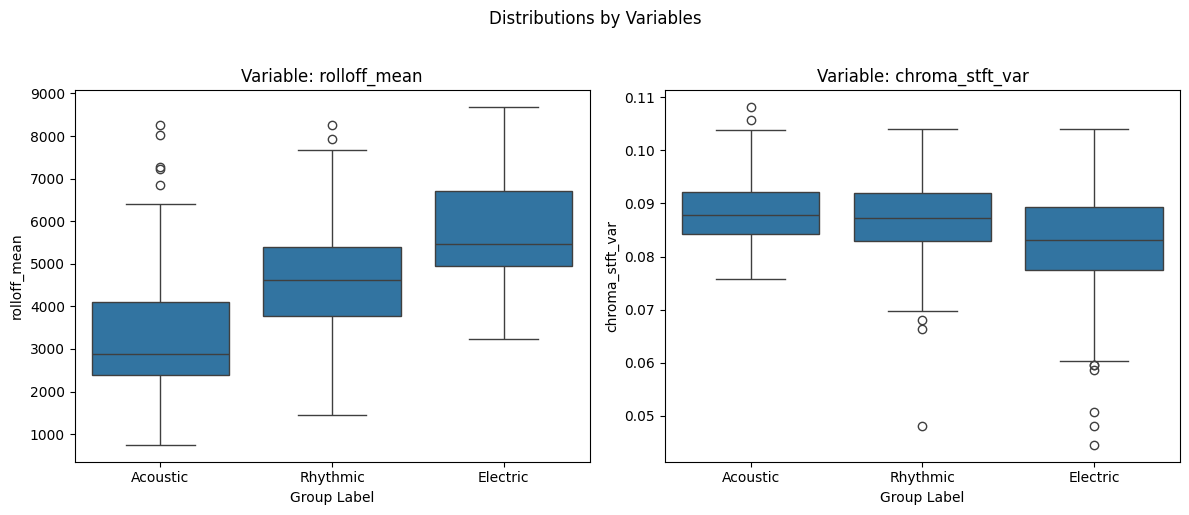

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature in zip(axes, ['rolloff_mean', 'chroma_stft_var']):
    sns.boxplot(data=df, x=df['final_group'], y=feature, 
                order=['Acoustic', 'Rhythmic', 'Electric'], ax=ax)
    ax.set_title(f'Variable: {feature}')
    ax.set_xlabel('Group Label')
    ax.set_ylabel(feature)

plt.suptitle('Distributions by Variables', y=1.02)
plt.tight_layout()
plt.show()

### To much overlap with chroma_stft_var boxplot (no clear distinctions), will only use rolloff_mean (due to stepwise pattern) for the baseline model.

In [ ]:
def classify_super_genre(rolloff):
    if rolloff < 4000:
        return 'Acoustic'
    elif 4000 <= rolloff < 5000:
        return 'Rhythmic'
    elif rolloff >= 5000:
        return 'Electric'
    else:
        return 'Unclassified'

df['predicted_super_genre'] = df['rolloff_mean'].apply(classify_super_genre)
print(df['predicted_super_genre'].value_counts())

predicted_super_genre
Electric    405
Acoustic    357
Rhythmic    238
Name: count, dtype: int64


In [11]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
y_true = df['final_group']
y_pred = df['predicted_super_genre']

accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_macro = f1_score(y_true, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Weighted F1:", f1_weighted)
print("Macro F1:", f1_macro)
print(classification_report(y_true, y_pred))

Accuracy: 0.552
Weighted F1: 0.5316846370010724
Macro F1: 0.5489634246023757
              precision    recall  f1-score   support

    Acoustic       0.61      0.73      0.66       300
    Electric       0.53      0.71      0.61       300
    Rhythmic       0.50      0.30      0.38       400

    accuracy                           0.55      1000
   macro avg       0.55      0.58      0.55      1000
weighted avg       0.54      0.55      0.53      1000



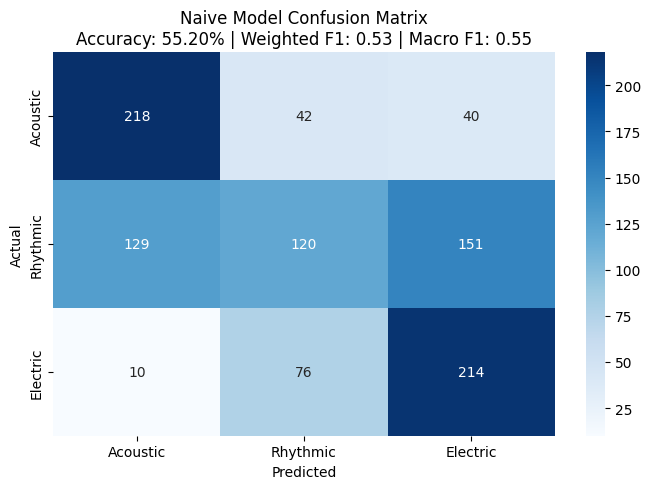

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['Acoustic', 'Rhythmic', 'Electric']

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Naive Model Confusion Matrix\nAccuracy: {accuracy:.2%} | Weighted F1: {f1_weighted:.2f} | Macro F1: {f1_macro:.2f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()